# Análise Exploratória de Dados — Churn de Clientes

## Contexto
Este notebook explora o dataset de churn de uma empresa de telecomunicações.
O objetivo é entender o perfil dos clientes que cancelam o serviço e identificar
os principais fatores associados ao churn.

## Fonte dos dados
Dados extraídos do BigQuery — tabela `churn_dataset.customers_cleaned`

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

from bigquery_client import run_query

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'font.family': 'sans-serif',
})
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

In [7]:
# Carregando dados do BigQuery
df = run_query("""
    SELECT *
    FROM `churn_dataset.customers_cleaned`
""")

print(f"Shape: {df.shape}")
print(f"\nTipos das colunas:")
print(df.dtypes)

c:\Users\Augusto\Desktop\Projetos\churn-analysis\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Shape: (7043, 23)

Tipos das colunas:
customerID              str
gender                  str
SeniorCitizen       boolean
Partner             boolean
Dependents          boolean
tenure                Int64
PhoneService        boolean
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling    boolean
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
tenure_group            str
AvgMonthlySpend     float64
Churn               boolean
dtype: object


In [8]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f"{churn_counts}\n\n{churn_pct}")


Churn
False    5174
True     1869
Name: count, dtype: Int64

Churn
False    73.463013
True     26.536987
Name: proportion, dtype: Float64


## 1. Visão Geral do Dataset

O dataset contém **7.043 clientes** com **23 features** cada, extraídos diretamente 
do BigQuery após as transformações de limpeza e enriquecimento realizadas via SQL.

### Distribuição do Churn

| Status | Clientes | Proporção |
|--------|----------|-----------|
| Ativos | 5.174 | 73,5% |
| Churn | 1.869 | 26,5% |

O dataset apresenta **desbalanceamento de classes** — apenas 26,5% dos clientes 
cancelaram o serviço. Isso é comum em problemas reais de churn e será tratado 
durante a modelagem para evitar que o modelo fique viciado em prever sempre "ativo".

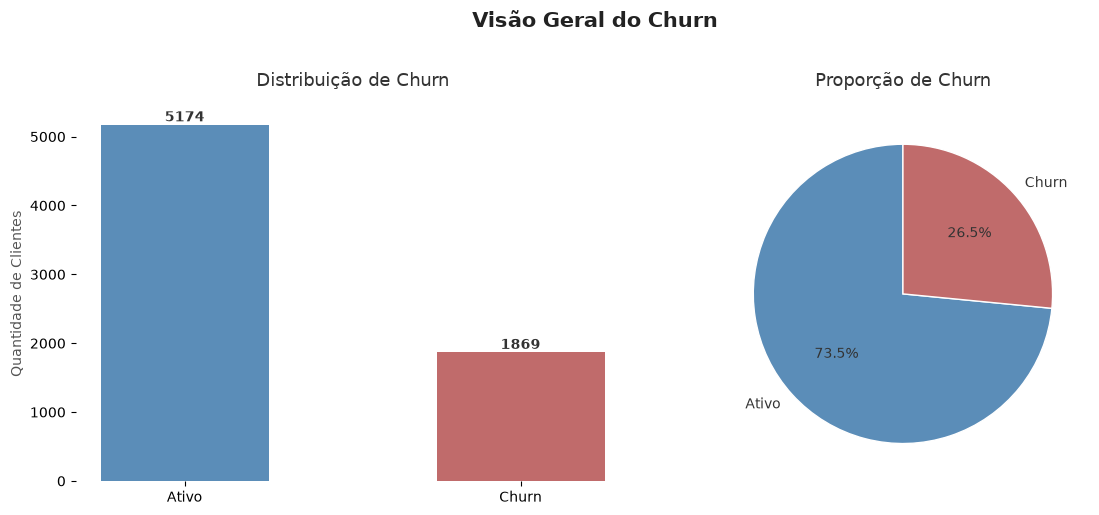

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Ativo', 'Churn'], churn_counts.values, color=['#5B8DB8', '#C06B6B'], width=0.5, zorder=3)
axes[0].set_title('Distribuição de Churn', fontsize=13, pad=15, color='#333333')
axes[0].set_ylabel('Quantidade de Clientes', color='#555555')

for container in axes[0].containers:
    axes[0].bar_label(container, fontweight='bold', color='#333333')

# Gráfico de pizza
axes[1].pie(
    churn_counts.values,
    labels=['Ativo', 'Churn'],
    autopct='%1.1f%%',
    colors=['#5B8DB8', '#C06B6B'],
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    textprops={'color': '#333333'},
)
axes[1].set_title('Proporção de Churn', fontsize=13, pad=15, color='#333333')

plt.suptitle('Visão Geral do Churn', fontsize=15, fontweight='bold', color='#222222', y=1.02)
plt.tight_layout()
plt.show()

## 2. Análise das Variáveis Numéricas

As três principais variáveis numéricas do dataset são **tenure** (tempo de permanência em meses), 
**MonthlyCharges** (valor da mensalidade) e **TotalCharges** (valor total gasto pelo cliente).

O objetivo aqui é entender a distribuição dessas variáveis e identificar se existe 
diferença de comportamento entre clientes que cancelaram e os que permaneceram — 
o que pode indicar que essas variáveis têm poder preditivo para o modelo.

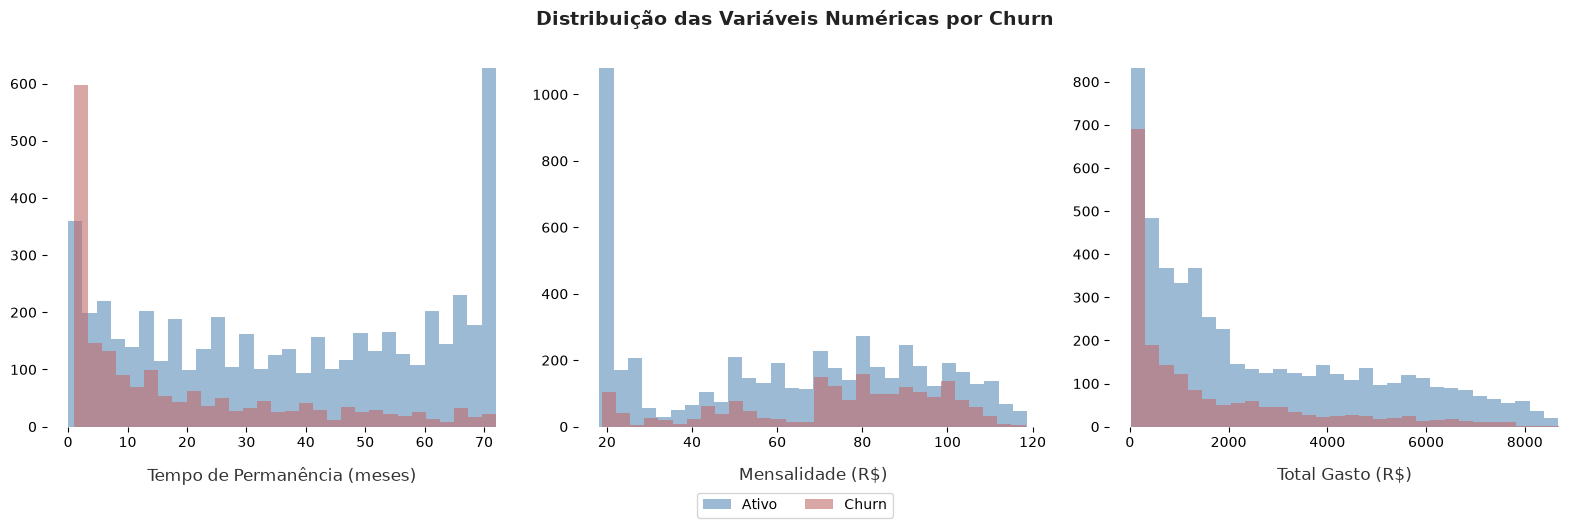

In [10]:
fig, axes = plt.subplots(1, 3, figsize = (16, 5))

numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
titulos = ['Tempo de Permanência (meses)', 'Mensalidade (R$)', 'Total Gasto (R$)']

for i, (col, titulo) in enumerate(zip(numericas, titulos)):
    for churn, label, cor in [(False, 'Ativo', '#5B8DB8'), (True, 'Churn', '#C06B6B')]:
        axes[i].hist(
            df[df['Churn'] == churn][col].dropna(),
            bins = 30, alpha = 0.6, label = label, color = cor
        )
    axes[i].set_xlabel(titulo, fontsize=12, labelpad=12, color='#333333')
    


plt.suptitle('Distribuição das Variáveis Numéricas por Churn', fontsize=14, fontweight='bold', color='#222222')
plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.show()

### Insights — Variáveis Numéricas

#### Tempo de Permanência (tenure)
Clientes em churn se concentram fortemente nos **primeiros 1-2 meses** de contrato, 
com queda acentuada após esse período. Isso indica que o período crítico de retenção 
é o início do relacionamento — clientes que sobrevivem aos primeiros meses tendem a 
permanecer. Vale notar dois picos distintos nos clientes ativos: um no início e outro 
próximo aos 70 meses, sugerindo dois perfis — novos clientes ainda em experiência e 
clientes altamente fidelizados.

#### Mensalidade (MonthlyCharges)
Clientes em churn tendem a ter mensalidades **mais altas**, concentradas acima de 
R$ 60-80. Clientes ativos têm distribuição mais espalhada, com muitos pagando valores 
mais baixos. Há um pico isolado próximo a R$ 20 que pode representar um plano básico 
específico — vale investigar sua taxa de churn separadamente.

#### Total Gasto (TotalCharges)
A alta concentração de churn no primeiro bin confirma o insight do tenure: clientes 
que cancelam acumularam **pouco gasto total** simplesmente porque ficaram pouco tempo. 
Isso reforça que a perda ocorre cedo no ciclo de vida do cliente.

#### Atenção — Multicolinearidade
`TotalCharges` e `tenure` são naturalmente correlacionados — quem permanece mais tempo 
acumula mais gasto. Isso será avaliado formalmente através do **VIF (Variance Inflation 
Factor)** durante a modelagem.

## 3. Análise das Variáveis Categóricas

As variáveis categóricas descrevem o perfil contratual e de serviços de cada cliente.
O objetivo é identificar quais categorias concentram maior taxa de churn, gerando
insights acionáveis para o negócio — como quais tipos de contrato ou serviços estão
mais associados ao cancelamento.

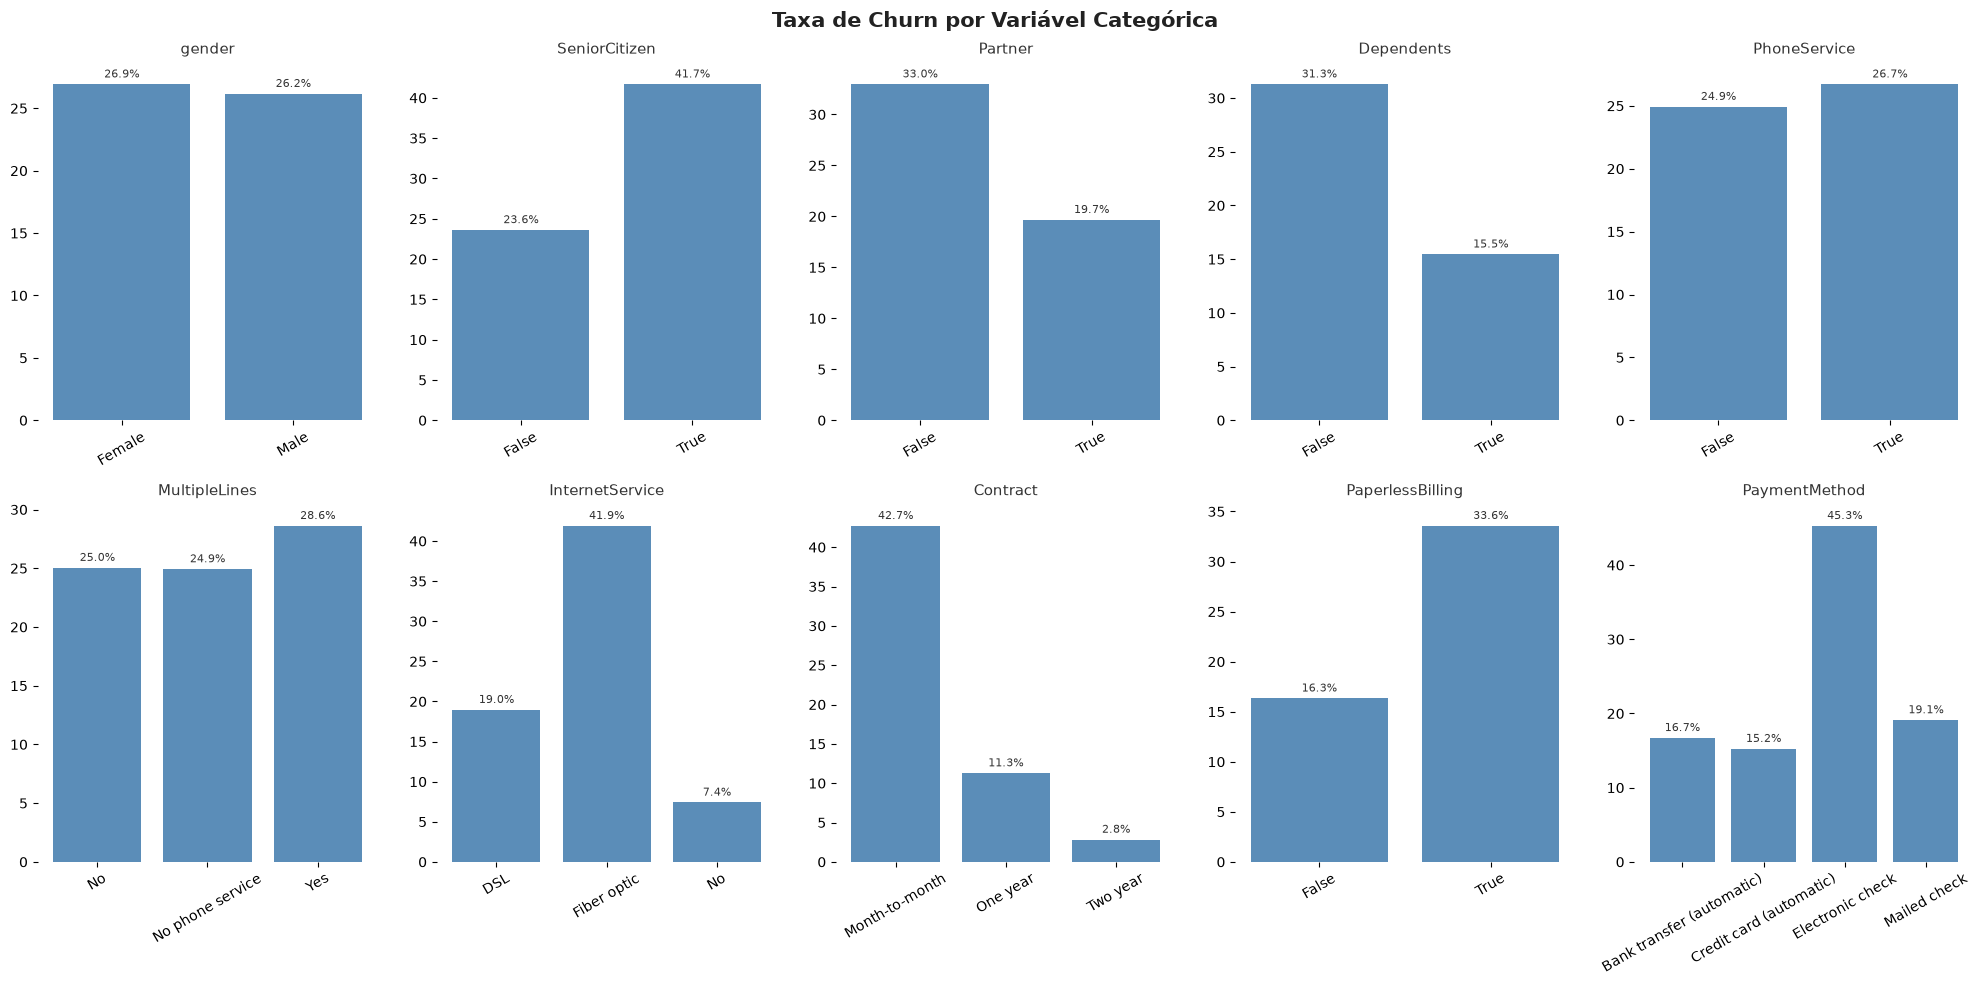

In [22]:
categoricas = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(2, 5, figsize = (20, 10))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    temp = df.copy()
    temp[col] = temp[col].astype(str)
    churn_rate = temp.groupby(col)['Churn'].mean() * 100
    axes[i].bar(churn_rate.index, churn_rate.values, color = '#5B8DB8')
    axes[i].set_title(col, fontsize = 11, pad = 10, color = '#333333')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis = 'x', rotation = 30)
    
    bars = axes[i].bar(churn_rate.index, churn_rate.values, color='#5B8DB8')
    axes[i].bar_label(bars, fmt='%.1f%%', fontsize=8, color='#333333', padding=3)

plt.suptitle('Taxa de Churn por Variável Categórica', fontsize=15, fontweight='bold', color='#222222')
plt.tight_layout()
plt.show()

### Insights — Variáveis Categóricas

#### Gênero (gender)
A taxa de churn entre homens (26.2%) e mulheres (26.9%) é praticamente idêntica,
indicando que **gênero não é um fator relevante** para o cancelamento. Essa variável
provavelmente terá baixo poder preditivo no modelo.

#### Idosos (SeniorCitizen)
Clientes idosos apresentam taxa de churn de **41.7%**, quase o dobro dos não idosos (23.6%).
Esse grupo merece atenção especial da área de retenção.

> **Contramedida:** Criar programas de fidelização específicos para clientes idosos,
> como atendimento prioritário, descontos por fidelidade ou planos simplificados.

#### Estado Civil e Dependentes (Partner + Dependents)
Clientes sem parceiro (33.0%) e sem dependentes (31.3%) cancelam mais do que os que
possuem família constituída. A combinação dos dois sugere que **clientes solteiros e
sem filhos têm menor vínculo emocional e financeiro** com o serviço, tornando o
cancelamento uma decisão mais simples.

> **Contramedida:** Ofertas de planos família e benefícios para múltiplos usuários
> podem aumentar o engajamento desse perfil.

#### Serviço de Telefone (PhoneService) e Múltiplas Linhas (MultipleLines)
Ambas as variáveis apresentam diferenças insignificantes nas taxas de churn.
**Não parecem ser fatores determinantes** para o cancelamento e provavelmente
terão baixo peso no modelo preditivo.

#### Serviço de Internet (InternetService)
Clientes com **Fiber optic** apresentam a maior taxa de churn (41.9%), muito acima
dos clientes DSL (19.0%) e dos sem internet (7.4%). Isso é um sinal de alerta —
a qualidade ou o custo-benefício do serviço de fibra ótica pode estar abaixo
das expectativas dos clientes.

> **Contramedida:** Investigar reclamações e NPS específicos do serviço de fibra.
> Ações de melhoria de qualidade ou reposicionamento de preço podem reduzir
> significativamente o churn geral.

#### Tipo de Contrato (Contract)
O contrato **Month-to-month** concentra 42.7% de churn — a barreira de saída é baixa,
sem multa ou compromisso de longo prazo. Contratos anuais (11.3%) e bianuais (2.8%)
apresentam churn muito inferior.

> **Contramedida:** Incentivar a migração para contratos mais longos através de
> descontos progressivos, benefícios exclusivos ou períodos de fidelidade com
> vantagens acumuladas.

#### Fatura Digital (PaperlessBilling)
Clientes com fatura digital cancelam mais (33.6% vs 16.3%). Esse perfil é
tipicamente mais conectado, compara planos com facilidade online e tem
menor fricção para cancelar — o processo é todo digital.

> **Contramedida:** Investir em experiência digital de qualidade, comunicação
> proativa e ofertas personalizadas via aplicativo para engajar esse perfil
> antes que ele considere o cancelamento.

#### Método de Pagamento (PaymentMethod)
Clientes que pagam via **cheque eletrônico** lideram o churn com 45.3%. Esse método
é mais manual e trabalhoso, sugerindo um perfil menos comprometido com o serviço —
quem não configurou débito automático demonstra menor vínculo com a empresa.

> **Contramedida:** Incentivar a migração para débito automático ou cartão de
> crédito com benefícios como desconto na mensalidade, reduzindo a fricção
> e aumentando a sensação de comprometimento.

## 4. Análise de Correlação

A matriz de correlação nos permite identificar quais variáveis numéricas possuem
maior relação linear com o churn, além de detectar possíveis casos de multicolinearidade
entre as features — algo que será tratado formalmente durante a modelagem.

In [43]:
corr_df = df.copy()
corr_df['Churn'] = corr_df['Churn'].astype(int)

numericas_corr = corr_df.select_dtypes(include=['number']).columns.tolist()

corr_matrix = corr_df[numericas_corr].corr()